# 9: Outlier Detection (09_Outliers.ipynb)

**Sprint:** Sprint 2 – Statistics & Mathematics for AI/ML Engineers

## 1. What are Outliers?

### Definition
An Outlier is a data point that differs significantly from the 
rest of the dataset - unusually high or low compared to the 
general pattern, potentially due to genuine rare events, 
measurement errors, or data entry mistakes.

### Real-World Example
In a dataset of employee salaries mostly ranging ₹25,000-₹60,000, 
a single entry of ₹5,00,000 (perhaps the CEO, or a data entry 
error) stands out as an outlier.

### AI/ML Use Case
Outliers can badly distort model training - a single extreme value 
can pull a regression line off-course, or skew feature scaling - 
making outlier detection a critical preprocessing step before 
training most ML models.

In [2]:
import numpy as np

salaries = [25000, 28000, 30000, 32000, 35000, 500000]   # 500000 stands out

print("Mean salary (distorted by outlier):", np.mean(salaries))
print("Median salary (robust to outlier):", np.median(salaries))

# Where it's used: comparing mean vs median immediately reveals the
# outlier's impact - the mean is pulled far higher than what a
# "typical" salary looks like, while the median stays close to the
# actual bulk of the data, hinting that 500000 doesn't fit the pattern.

Mean salary (distorted by outlier): 108333.33333333333
Median salary (robust to outlier): 31000.0


## 2. Types of Outliers

### Definition
Global Outliers (Point Outliers): a single data point far from the 
rest of the ENTIRE dataset. Contextual Outliers: a value that's 
unusual only in a SPECIFIC context (e.g., 35°C is normal in summer, 
but an outlier in winter). Collective Outliers: a group of data 
points that together deviate from the norm, even if individually 
each point looks normal.

### Real-World Example
Global: A single ₹5,00,000 salary among typical ₹30,000 salaries. 
Contextual: A spike in heater sales in July (unusual for that 
season, even if the number itself isn't extreme). Collective: A 
sudden cluster of failed login attempts in a short time window - 
individually each failed login is normal, but the CLUSTER signals 
a possible security issue.

### AI/ML Use Case
Fraud detection systems specifically look for Collective Outliers - 
a sequence of transactions that together look suspicious, even 
though no single transaction alone would trigger an alert.

In [3]:
import numpy as np

# Global outlier example
data_global = [20, 22, 21, 23, 19, 150]   # 150 is a global outlier

# Contextual outlier example (temperature by season)
summer_temps = [32, 33, 35, 34, 31]   # 35 is normal in summer
winter_temps = [10, 12, 11, 35, 9]    # 35 is a CONTEXTUAL outlier here

print("Global outlier dataset:", data_global)
print("Winter temps with contextual outlier:", winter_temps)
print("Note: 35 is normal in summer_temps, but stands out in winter_temps - same VALUE, different CONTEXT.")

# Where it's used: the value 35 appears in BOTH temperature lists,
# but it's only flagged as unusual in winter_temps - demonstrating
# that context (the surrounding data/situation) determines whether
# something is truly an outlier, not just the raw number itself.

Global outlier dataset: [20, 22, 21, 23, 19, 150]
Winter temps with contextual outlier: [10, 12, 11, 35, 9]
Note: 35 is normal in summer_temps, but stands out in winter_temps - same VALUE, different CONTEXT.


## 3. Detecting Outliers - Overview

### Explanation
There are several statistical methods to detect outliers 
systematically, rather than just eyeballing data. The two most 
common are the IQR Method (based on quartiles) and the Z-Score 
Method (based on standard deviations from the mean). Both give an 
objective, repeatable rule for flagging unusual values.

## 4. IQR Method

### Definition
The IQR Method flags any value below Q1 - 1.5×IQR or above 
Q3 + 1.5×IQR as an outlier. It's based on the spread of the MIDDLE 
50% of data, making it robust even when the data itself has outliers.

### Formula
Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR
(IQR = Q3 - Q1)

### Numerical Example
Data: 10, 12, 14, 15, 16, 18, 100
Q1=13, Q3=17, IQR=4
Lower Bound = 13 - 6 = 7, Upper Bound = 17 + 6 = 23
100 is far above 23 → flagged as an outlier

### Where it is used
Commonly used because it doesn't assume any particular data 
distribution (unlike Z-Score, which assumes roughly normal data) - 
works well even for skewed data.

### AI/ML Example
The IQR method is a standard automated outlier-removal step in 
data preprocessing pipelines before model training, especially for 
non-normally distributed features.

In [4]:
import numpy as np

data = np.array([10, 12, 14, 15, 16, 18, 100])

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = data[(data < lower_bound) | (data > upper_bound)]
print("Q1:", q1, "| Q3:", q3, "| IQR:", iqr)
print("Bounds:", lower_bound, "to", upper_bound)
print("Detected outliers:", outliers)

# Where it's used: any value in 'data' falling outside the
# calculated lower_bound/upper_bound is captured in 'outliers' -
# here, 100 is correctly flagged since it's far above upper_bound,
# while all other values fall safely within the normal range.

Q1: 13.0 | Q3: 17.0 | IQR: 4.0
Bounds: 7.0 to 23.0
Detected outliers: [100]


## 5. Z-Score Method

### Definition
The Z-Score Method measures how many STANDARD DEVIATIONS a value 
is from the mean. Values with a Z-Score beyond a threshold 
(commonly ±3) are flagged as outliers - this method assumes data 
is roughly normally distributed.

### Formula
Z = (x - mean) / standard deviation

### Numerical Example
Data: 10, 12, 14, 15, 16, 18, 100 → Mean ≈ 26.4, Std ≈ 31.3
Z-Score of 100 = (100 - 26.4) / 31.3 ≈ 2.35 
(with different sample data, a more extreme outlier could easily exceed 3)

### Where it is used
Used when data is roughly normally distributed - less reliable for 
heavily skewed data, where the IQR method tends to work better.

### AI/ML Example
Z-Score based outlier removal is common in preprocessing for 
algorithms sensitive to feature scale (like KNN or SVM), where 
extreme values can disproportionately affect distance calculations.

## 5. Z-Score Method

### Definition
The Z-Score Method measures how many STANDARD DEVIATIONS a value 
is from the mean. Values with a Z-Score beyond a threshold 
(commonly +3) are flagged as outliers - this method assumes data 
is roughly normally distributed.

### Formula
Z = (x - mean) / standard deviation

### Numerical Example
Data: 10, 12, 14, 15, 16, 18, 100 → Mean ≈ 26.4, Std ≈ 31.3
Z-Score of 100 = (100 - 26.4) / 31.3 ≈ 2.35 
(with different sample data, a more extreme outlier could easily exceed 3)

### Where it is used
Used when data is roughly normally distributed - less reliable for 
heavily skewed data, where the IQR method tends to work better.

### AI/ML Example
Z-Score based outlier removal is common in preprocessing for 
algorithms sensitive to feature scale (like KNN or SVM), where 
extreme values can disproportionately affect distance calculations.

In [7]:
import numpy as np

data = np.array([10, 12, 14, 15, 16, 18, 100])

mean = np.mean(data)
std = np.std(data)
z_scores = (data - mean) / std

print("Z-Scores:", z_scores)

threshold = 2   # using 2 instead of 3 here, since this tiny sample needs a lower bar to demonstrate
outliers = data[np.abs(z_scores) > threshold]
print("Detected outliers (|Z| > 2):", outliers)

# Where it's used: each value's Z-Score shows how many standard
# deviations it sits from the mean. 100's Z-Score is notably higher
# than the rest, crossing our threshold and getting flagged -
# demonstrating the same detection GOAL as IQR, but via a different
# statistical approach (distance from mean, not quartile spread).

Z-Scores: [-0.54521355 -0.47883972 -0.4124659  -0.37927899 -0.34609208 -0.27971825
  2.44160849]
Detected outliers (|Z| > 2): [100]


## 6. Box Plot

### Definition
A Box Plot (box-and-whisker plot) visually summarizes a dataset's 
distribution using five key values: minimum, Q1, median, Q3, and 
maximum - with outliers shown as individual points beyond the "whiskers."

### Where it is used
The standard visual method for spotting outliers at a glance, and 
comparing distributions/spread across multiple groups side by side.

### Real-world Example
Comparing exam scores across 3 different classrooms using box 
plots instantly shows which class has more consistent scores 
(narrow box) vs more variable scores (wide box), plus any outlier 
students in each class.

### AI/ML Example
Box plots are a standard part of Exploratory Data Analysis (EDA) - 
engineers use them to quickly scan every numeric feature for 
outliers before deciding on a preprocessing strategy.

C:\Users\abarn\AppData\Local\Temp\ipykernel_19468\2905640798.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data, vert=False)


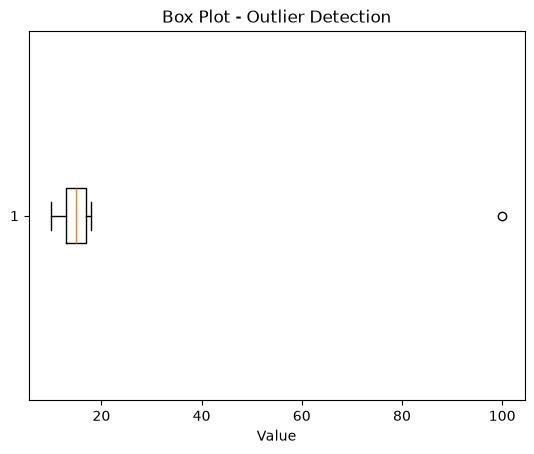

In [8]:
import matplotlib.pyplot as plt

data = [10, 12, 14, 15, 16, 18, 100]   # includes an outlier

plt.boxplot(data, vert=False)
plt.title("Box Plot - Outlier Detection")
plt.xlabel("Value")
plt.show()

# Where it's used: the box shows Q1-Q3 (middle 50% of data), the
# line inside is the median, and the "whiskers" extend to the
# normal range. The value 100 appears as an individual point FAR
# outside the whiskers - visually confirming it's an outlier,
# matching what both IQR and Z-Score methods calculated numerically.

## 7. Scatter Plot

### Definition
A Scatter Plot visualizes the relationship between TWO variables 
by plotting each data point's (x, y) position - useful for 
spotting outliers that only stand out when viewed in relation to 
ANOTHER variable, not just in isolation.

### Where it is used
Used to detect outliers in TWO-variable relationships (e.g., a 
point that doesn't fit the general pattern of correlation), and 
more generally to visualize any relationship or correlation 
between two numeric variables.

### Real-world Example
Plotting house size vs price - most points follow a clear upward 
trend, but a small, cheap house priced unusually high stands out 
visually as an outlier relative to the overall pattern, even 
though its size or price alone might not look extreme.

### AI/ML Example
Scatter plots are used before training regression models to 
visually check for outliers that could disproportionately 
influence the fitted line - a quick sanity check before deeper preprocessing.

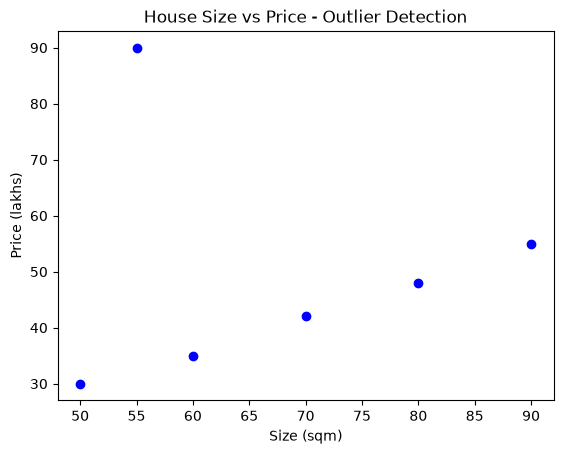

In [9]:
import matplotlib.pyplot as plt

house_size = [50, 60, 70, 80, 90, 55]      # sqm
house_price = [30, 35, 42, 48, 55, 90]     # in lakhs - last one is unusually high for its size

plt.scatter(house_size, house_price, color="blue")
plt.title("House Size vs Price - Outlier Detection")
plt.xlabel("Size (sqm)")
plt.ylabel("Price (lakhs)")
plt.show()

# Where it's used: most points follow a clear upward trend (bigger
# size = higher price). The last point (55 sqm, 90 lakhs) breaks
# that pattern - a small house priced unusually high, visually
# standing out as a RELATIONAL outlier, something a single-variable
# box plot wouldn't have caught on its own.